In [2]:
import os
import scipy
import pandas as pd
import numpy as np
from geopy.distance import geodesic
from haversine import haversine, Unit

In [3]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [4]:
runway_df = pd.read_excel("C:/Users/HP/Desktop/ML/project/HoneyWell-Analysis-main/HoneyWell-Analysis-main/Earlier Work/Work_June_Presentation/RunwayDatabase_2007_USA.xlsx")

In [5]:
def format_latitude(l):
    factor = -1 if 'S' in l else 1
    l = l.strip('N')
    l = l.strip('S')
    l = l.strip()
    l_split = l.split(' ')
    l_degree , l_min , l_sec = l_split[0] , l_split[1] , l_split[2]
    l_degrees = float(l_degree) + float(l_min)/60 + float(l_sec)/3600
    return  factor * l_degrees 
def format_longitude(l):
    factor = -1 if 'W' in l else 1
    l = l.strip('W')
    l = l.strip('E')
    l = l.strip()
    l_split = l.split(' ')
    l_degree , l_min , l_sec = l_split[0] , l_split[1] , l_split[2]
    l_degrees = float(l_degree) + float(l_min)/60 + float(l_sec)/3600
    return  factor * l_degrees


In [6]:
runway_df['Latitude'] = runway_df['FORMATTED LATITUDE'].apply(lambda x : format_latitude(x))
runway_df['Longitude'] = runway_df['FORMATTED LONGITUDE'].apply(lambda x : format_longitude(x))
runway_df['combined_coordinates'] = runway_df.apply(lambda row: [row['Latitude'], row['Longitude']], axis=1)

In [7]:
MagneticHeadingDataLanding = pd.read_csv("MagneticHeadingDataLanding.csv")
N1ApproachTouchdownCoordinates = pd.read_csv("C:/Users/HP/Desktop/ML/project/piyush_prashans_dhawal/N1ApproachTouchdownCoordinates.csv")

In [8]:
MagneticHeadingDataLanding["MagneticHeadingMean"] = MagneticHeadingDataLanding["MagneticHeading"].apply(lambda x: np.mean(np.fromstring(x.strip("[]"), sep=" ")))

# Display the updated DataFrame
MagneticHeadingDataLanding['MagneticHeadingMeanUpdated'] = MagneticHeadingDataLanding['MagneticHeadingMean'].apply(lambda x: x if x>=0 else x+360)
N1ApproachTouchdownCoordinates['MagneticHeadingUpdated'] =N1ApproachTouchdownCoordinates['MagneticHeading'].apply(lambda x: x if x>=0 else x+360)

c:\Users\HP\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\HP\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [14]:
runway_df.to_csv("runway_df.csv", index=False)

### Approach 1
__Using just magnetic heading of the flight and comparing it with the magnetic bearings of all the runways__

In [13]:
def angular_difference(heading, bearing):
    diff = np.abs(heading - bearing)
    return np.minimum(diff, 360 - diff)  # Keep difference in range [0, 180]

# Compute difference for each flight against all runways
def calculateMinAlignment(heading):
    angularDiff = runway_df['MagBearing'].apply(lambda x: angular_difference(heading, x))
    minIdx = angularDiff.idxmin()
    minDiff = angularDiff.min()
    return minDiff

def caculateMinIdx(heading):
    angularDiff = runway_df['MagBearing'].apply(lambda x: angular_difference(heading, x))
    minIdx = angularDiff.idxmin()
    return minIdx
MagneticHeadingDataLanding['MostAlignedValue'] = MagneticHeadingDataLanding['MagneticHeadingMeanUpdated'].apply(calculateMinAlignment)
MagneticHeadingDataLanding['MinIdx'] = MagneticHeadingDataLanding['MagneticHeadingMean'].apply(caculateMinIdx)
MagneticHeadingDataLanding['NearestRunway'] = MagneticHeadingDataLanding['MinIdx'].apply(lambda x: runway_df.loc[x,'Ident'])
MagneticHeadingDataLanding['NearestAirport'] = MagneticHeadingDataLanding['MinIdx'].apply(lambda x: runway_df.loc[x,'Airport'])

In [14]:
# print(runway_df.shape)
MagneticHeadingDataLanding.head()

,Flights,Timestamps,Touchdown_idx,Latitude,Longitude,MagneticHeading,MagneticHeadingMean,MagneticHeadingMeanUpdated,MostAlignedValue,MinIdx,NearestRunway,NearestAirport
0,666_8,666200306240517.mat,6619,35.030768,-89.972696,[-1.48860294 -1.64240772 -1.83466274 -2.043396...,-2.097640,357.902360,0.097640,256,RW36,KANE
1,666_8,666200306240815.mat,4849,35.398296,-97.588985,[173.6831665 173.51289368 173.3865509 173.33...,173.532801,173.532801,0.467199,81,RW17,KADM
2,666_8,666200306241019.mat,4458,35.049992,-89.975453,[177.95123291 177.98419189 178.03363037 178.08...,178.054916,178.054916,0.054916,351,RW18,KASD
3,666_8,666200306241258.mat,4954,35.400011,-97.588648,[173.36457825 173.34809875 173.3261261 173.29...,173.403715,173.403715,0.403715,33,RW17,KABR
4,666_8,666200306241521.mat,8702,42.222865,-83.368884,[-146.87184174 -146.6026767 -146.20718414 -14...,-145.841214,214.158786,0.158786,256,RW36,KANE


In [15]:
runway_df.loc[(runway_df['Ident'] == 'RW18') & (runway_df['Airport'] == 'KASD'), 'MagBearing']

351    178
Name: MagBearing, dtype: int64

In [16]:
# Let's predict Long Landing
from geopy.distance import geodesic

def touchdownDist(row):
    """
    Determines if a landing was 'long' based on touchdown distance from the start of the runway.
    
    Params:
    - touchdown_coords: (lat, lon) of where the aircraft touched down
    - runway_start_coords: (lat, lon) of runway threshold
    - runway_length: total length of the assigned runway in meters
    - threshold: fraction of runway length considered as long landing (default: 50%)
    
    Returns:
    - True if long landing, False otherwise
    """
    touchdown_coords = [row['Latitude'], row['Longitude']]
    runway_start_coords = row['RunwayCoords']
    runway_length = row['RWlength']
    distance = geodesic(touchdown_coords, runway_start_coords).feet
    return distance

In [17]:
runway_df['combined_coordinates'] = runway_df.apply(lambda row: [row['Latitude'], row['Longitude']], axis=1)

In [18]:
MagneticHeadingDataLanding['RunwayCoords'] = MagneticHeadingDataLanding['MinIdx'].apply(lambda x: runway_df.loc[x,'combined_coordinates'])

In [19]:
MagneticHeadingDataLanding['RWlength'] = MagneticHeadingDataLanding['MinIdx'].apply(lambda x: runway_df.loc[x,'Length'])

In [20]:
MagneticHeadingDataLanding['touchdownDistance'] = MagneticHeadingDataLanding.apply(touchdownDist, axis = 1)

In [71]:
toBeDropped = MagneticHeadingDataLanding.loc[:, 'MostAlignedValue':].columns.tolist()
MagneticHeadingDataLanding.drop(columns = toBeDropped, inplace=True)

In [72]:
MagneticHeadingDataLanding.head()

,Flights,Timestamps,Touchdown_idx,Latitude,Longitude,MagneticHeading,MagneticHeadingMean,MagneticHeadingMeanUpdated
0,666_8,666200306240517.mat,6619,35.030768,-89.972696,[-1.48860294 -1.64240772 -1.83466274 -2.043396...,-2.097640,357.902360
1,666_8,666200306240815.mat,4849,35.398296,-97.588985,[173.6831665 173.51289368 173.3865509 173.33...,173.532801,173.532801
2,666_8,666200306241019.mat,4458,35.049992,-89.975453,[177.95123291 177.98419189 178.03363037 178.08...,178.054916,178.054916
3,666_8,666200306241258.mat,4954,35.400011,-97.588648,[173.36457825 173.34809875 173.3261261 173.29...,173.403715,173.403715
4,666_8,666200306241521.mat,8702,42.222865,-83.368884,[-146.87184174 -146.6026767 -146.20718414 -14...,-145.841214,214.158786


### Approach 2
__Combining Magnetic Alignment and Haversine (point-wise) distance both, weighing them and assigning the least of these to the flight__

In [32]:
import numpy as np
from numba import njit, prange

# Vectorized and JIT-compiled Haversine function
@njit(parallel=True)
def haversine_matrix(lat1, lon1, lat2_arr, lon2_arr):
    R = 6371 * 3280.84  # Earth radius in feet
    n_flights = lat1.shape[0]
    n_runways = lat2_arr.shape[0]
    result = np.empty((n_flights, n_runways))

    for i in prange(n_flights):
        for j in range(n_runways):
            dlat = np.radians(lat2_arr[j] - lat1[i])
            dlon = np.radians(lon2_arr[j] - lon1[i])
            a = (np.sin(dlat / 2) ** 2 +
                 np.cos(np.radians(lat1[i])) * np.cos(np.radians(lat2_arr[j])) * np.sin(dlon / 2) ** 2)
            c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
            result[i, j] = R * c
    return result

def compute_combined_scores_optimized(MagneticHeadingDataLanding, runway_df):
    flight_headings = MagneticHeadingDataLanding['MagneticHeadingMeanUpdated'].values
    touchdown_coords = MagneticHeadingDataLanding[['Latitude', 'Longitude']].values
    lat1 = touchdown_coords[:, 0]
    lon1 = touchdown_coords[:, 1]

    runway_bearings = runway_df['MagBearing'].values
    runway_coords = np.array(runway_df['Starting Coordinates'].tolist())
    lat2 = runway_coords[:, 0]
    lon2 = runway_coords[:, 1]

    # Angular difference (vectorized)
    angular_diff_matrix = np.minimum(
        np.abs(flight_headings[:, None] - runway_bearings),
        360 - np.abs(flight_headings[:, None] - runway_bearings)
    )

    # Efficient Haversine distance matrix
    haversine_dist_matrix = haversine_matrix(lat1, lon1, lat2, lon2)

    # Normalize per flight
    angular_diff_norm = (angular_diff_matrix - angular_diff_matrix.mean(axis=1, keepdims=True)) / angular_diff_matrix.std(axis=1, keepdims=True)
    haversine_dist_norm = (haversine_dist_matrix - haversine_dist_matrix.mean(axis=1, keepdims=True)) / haversine_dist_matrix.std(axis=1, keepdims=True)

    # Weighted combination
    w1, w2 = 0.3, 0.7
    combined_scores = w1 * angular_diff_norm + w2 * haversine_dist_norm

    MagneticHeadingDataLanding['MinIdx'] = np.argmin(combined_scores, axis=1)
    return MagneticHeadingDataLanding, angular_diff_matrix, haversine_dist_matrix, angular_diff_norm, haversine_dist_norm

In [33]:
subsetDf = MagneticHeadingDataLanding.loc[MagneticHeadingDataLanding['Flights'].str.contains('667')].reset_index(drop=True)
subsetDf, A, P, A_n, P_n = compute_combined_scores_optimized(subsetDf, runway_df)

In [34]:
subsetDf['NearestRunway'] = subsetDf['MinIdx'].apply(lambda x: runway_df.loc[x,'Ident'])
subsetDf['NearestAirport'] = subsetDf['MinIdx'].apply(lambda x: runway_df.loc[x,'Airport'])
subsetDf['AirportCoords'] = subsetDf['MinIdx'].apply(lambda x: runway_df.loc[x,'Starting Coordinates'])

In [38]:
subsetDf.head()

,Flights,Timestamps,Touchdown_idx,Latitude,Longitude,MagneticHeading,MagneticHeadingMean,MagneticHeadingMeanUpdated,MinIdx,NearestRunway,NearestAirport,AirportCoords
0,667_667,667200103250913.mat,4667,35.057203,-89.961361,[-88.75040466 -89.1788562 -89.53041107 -89.84...,-89.855184,270.144816,4092,RW27,KMEM,"[35.057786111111106, -89.95585833333334]"
1,667_667,667200106121039.mat,7325,44.889453,-93.213668,[119.1157074 119.14317322 119.19810486 119.29...,119.408896,119.408896,4437,RW12L,KMSP,"[44.892941666666665, -93.2209888888889]"
2,667_667,667200105101309.mat,2733,43.589117,-96.742860,[148.00889587 148.22311401 148.51974487 148.79...,148.752504,148.752504,2341,RW15,KFSD,"[43.593125, -96.74606666666666]"
3,667_667,667200104191216.mat,6977,35.399667,-97.588648,[171.55189514 171.55189514 171.66174316 171.82...,171.953566,171.953566,4837,RW17L,KOKC,"[35.40515555555555, -97.58895833333332]"
4,667_667,667200105221309.mat,4610,35.813029,-83.987570,[-130.67297394 -130.68945343 -130.74987824 -13...,-130.957928,229.042072,6684,RW23R,KTYS,"[35.81604166666666, -83.99119722222223]"


In [36]:
subsetDf.loc[(subsetDf['NearestAirport'] == 'KCVG') & (subsetDf['NearestRunway'] == 'RW18R')]

,Flights,Timestamps,Touchdown_idx,Latitude,Longitude,MagneticHeading,MagneticHeadingMean,MagneticHeadingMeanUpdated,MinIdx,NearestRunway,NearestAirport,AirportCoords
21,667_667,667200104081747.mat,8006,39.058286,-84.668385,[-175.18275482 -175.22670014 -175.34754975 -17...,-175.621514,184.378486,1388,RW18R,KCVG,"[39.070886111111115, -84.68375]"
25,667_667,667200105030634.mat,3759,39.050735,-84.647767,[-175.48487885 -175.73754913 -175.90783722 -17...,-175.714209,184.285791,1388,RW18R,KCVG,"[39.070886111111115, -84.68375]"
37,667_667,667200106131744.mat,8067,39.058972,-84.668385,[-177.27009613 -177.01742584 -176.77572663 -17...,-176.621239,183.378761,1388,RW18R,KCVG,"[39.070886111111115, -84.68375]"
120,667_667,667200106161448.mat,4023,39.050218,-84.646389,[-176.63291962 -176.53404267 -176.42417938 -17...,-176.237418,183.762582,1388,RW18R,KCVG,"[39.070886111111115, -84.68375]"
128,667_667,667200104010437.mat,3485,39.048674,-84.647614,[-177.10531647 -176.9020694 -176.69882233 -17...,-176.514813,183.485187,1388,RW18R,KCVG,"[39.070886111111115, -84.68375]"
...,...,...,...,...,...,...,...,...,...,...,...,...
4185,667_667,667200308231823.mat,6408,39.061549,-84.668201,[-176.28135712 -176.20994599 -176.20994599 -17...,-176.179737,183.820263,1388,RW18R,KCVG,"[39.070886111111115, -84.68375]"
4235,667_667,667200308030545.mat,3609,39.058631,-84.668722,[-175.47389252 -175.55079682 -175.67163117 -17...,-175.962080,184.037920,1388,RW18R,KCVG,"[39.070886111111115, -84.68375]"
4320,667_667,667200308200637.mat,3353,39.058114,-84.668875,[-175.5068515 -175.44093353 -175.33656342 -17...,-175.105858,184.894142,1388,RW18R,KCVG,"[39.070886111111115, -84.68375]"
4329,667_667,667200309101346.mat,4407,39.059144,-84.667681,[-175.98474152 -175.79248078 -175.73205597 -17...,-175.813767,184.186233,1388,RW18R,KCVG,"[39.070886111111115, -84.68375]"


In [37]:
subsetDf.loc[subsetDf['Timestamps'] == '667200302101729.mat']

,Flights,Timestamps,Touchdown_idx,Latitude,Longitude,MagneticHeading,MagneticHeadingMean,MagneticHeadingMeanUpdated,MinIdx,NearestRunway,NearestAirport,AirportCoords
3802,667_667,667200302101729.mat,6970,39.060691,-84.667681,[-176.37474091 -176.40769989 -176.3912204 -17...,-176.269688,183.730312,1388,RW18R,KCVG,"[39.070886111111115, -84.68375]"


In [48]:
P[3802].mean()
P[3802].std()

A[3802].mean()
A[3802].std()

4172596.9137449223

2754502.1816600333

89.96109097915146

54.802998677641185

In [42]:
A[3802, 1388]
A[3802, 1386]

P[3802, 1388]
P[3802, 1386]

0.2696879612499856

2.2696879612499856

5877.937737339019

1500.3918892650797

In [53]:
logScaledP = np.log1p(P[3802])
logScaledP[1386]
logScaledP[1388]
logScaledP.mean()
logScaledP.std()

7.314147883009671

8.679131367657114

15.003772944891752

0.7633892253241072

In [44]:
A_n[3802, 1388]
A_n[3802, 1386]

P_n[3802, 1388]
P_n[3802, 1386]

-1.6366148784207724

-1.6001205250412378

-1.5126940191771643

-1.5142832522070817

In [22]:
def calculateDistToAirport(row):
    """
    Determines the distance between the aircraft and the nearest airport.
    
    Params:
    - coords: (lat, lon) of the aircraft
    - airport_coords: (lat, lon) of the nearest airport
    
    Returns:
    - Distance in feet
    """
    coords = [row['Latitude'], row['Longitude']]
    airport_coords = row['AirportCoords']
    distance = haversine(coords, airport_coords, unit = Unit.KILOMETERS)
    return distance

In [23]:
subsetDf['distanceToAirport'] = subsetDf.apply(calculateDistToAirport, axis = 1)

C:\Users\HP\AppData\Local\Temp\ipykernel_2156\4140417252.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subsetDf['distanceToAirport'] = subsetDf.apply(calculateDistToAirport, axis = 1)


In [24]:
subsetDf.loc[subsetDf['distanceToAirport']>5]

,Flights,Timestamps,Touchdown_idx,Latitude,Longitude,MagneticHeading,MagneticHeadingMean,MagneticHeadingMeanUpdated,MinIdx,NearestRunway,NearestAirport,AirportCoords,distanceToAirport
620,667_667,667200107030749.mat,7450,50.436176,-104.665903,[124.77349854 124.96575165 125.19096375 125.39...,125.340652,125.340652,5512,RW12,KPWD,"[48.79242222222222, -104.529975]",183.039422
774,667_667,667200106281330.mat,4482,35.050164,-89.975974,[-178.92349274 -179.17068512 -179.53321869 17...,44.542049,44.542049,4680,RW04,KNQA,"[35.3481, -89.87885555555555]",34.284133
795,667_667,667200106140746.mat,6987,50.427418,-104.653189,[-54.75972016 -54.72676117 -54.70478851 -54.67...,-54.525579,305.474421,5513,RW30,KPWD,"[48.78526111111111, -104.51799444444444]",182.859380
861,667_667,667200104130131.mat,150,0.000000,0.351562,[0 0 0 0 0 0 0 0],0.000000,0.000000,4493,RW36,KMVM,"[44.69945277777777, -67.47643333333333]",8277.344377
874,667_667,667200105021839.mat,5314,45.478936,-73.741429,[-121.67544586 -121.65347321 -121.6699527 -12...,-121.818951,238.181049,5441,RW24,KPTD,"[44.68031111111111, -74.9434888888889]",129.589173
...,...,...,...,...,...,...,...,...,...,...,...,...,...
60707,667_667,667200403051021.mat,7857,52.174762,-106.689446,[-94.36974365 -94.61692841 -94.7817157 -94.86...,-94.776225,265.223775,2541,RW26,KGGW,"[48.21283888888889, -106.60421944444444]",440.588084
60715,667_667,667200402221910.mat,5430,45.480138,-73.740923,[-121.10417206 -121.41178925 -121.61502106 -12...,-121.530567,238.469433,5441,RW24,KPTD,"[44.68031111111111, -74.9434888888889]",129.708990
60729,667_667,667200403021941.mat,5591,45.480824,-73.739376,[-123.24644501 -123.01573212 -122.74658234 -12...,-122.554325,237.445675,3978,RW23,KMAL,"[44.85823055555556, -74.32705833333333]",83.157142
60749,667_667,667200402151840.mat,6082,45.463833,-73.758615,[103.76826477 103.91108704 104.03192902 104.11...,104.114325,104.114325,2879,RW10,KHIE,"[44.36729166666667, -71.55346388888888]",212.160329


In [25]:
subsetDf['NearestAirport'].value_counts()

NearestAirport
KMSP    1036
KDTW     942
KMEM     513
KOKC     159
KCVG     155
        ... 
KSGS       1
KCBF       1
KHEG       1
KNQA       1
KPNN       1
Name: count, Length: 95, dtype: int64

In [26]:
import folium
import numpy as np

# Define the airport you want to analyze
selected_airport = "KCVG"

# Filter flights and runways for this airport
filtered_flights = subsetDf[subsetDf['NearestAirport'] == selected_airport]
filtered_runways = runway_df[runway_df['Airport'] == selected_airport]

# Get center of the map
center_lat, center_lon = filtered_flights[['Latitude', 'Longitude']].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=10)

# Assign unique colors to each runway
runway_ids = filtered_runways.index.unique()
colors = np.random.choice([
    'red', 'blue', 'green', 'purple', 'orange', 'darkred', 'cadetblue', 'darkblue'
], size=len(runway_ids), replace=True)
runway_color_map = dict(zip(runway_ids, colors))

# Plot runways
for idx, row in filtered_runways.iterrows():
    folium.Marker(
        location=row['Starting Coordinates'],
        icon=folium.Icon(color=runway_color_map[idx], icon="plane"),
        tooltip=f"Runway {idx}"
    ).add_to(m)

# Plot landings with directional lines and dot markers
for _, row in filtered_flights.iterrows():
    assigned_runway = row['MinIdx']
    flight_name = row.get('Flights', 'Unknown')
    timestamp = row.get('Timestamps', 'Unknown')
    
    # Heading details
    heading_angle = row['MagneticHeadingMeanUpdated']
    lat, lon = row['Latitude'], row['Longitude']
    
    # Calculate endpoint for the heading direction
    length = 0.0005  # Small line length for visual clarity
    end_lat = lat + length * np.cos(np.radians(heading_angle))
    end_lon = lon + length * np.sin(np.radians(heading_angle))

    # Tooltip details
    tooltip = (
        f"Flight: {flight_name}<br>"
        f"Timestamp: {timestamp}<br>"
        f"Runway: {assigned_runway}<br>"
    )

    # Draw directional line
    folium.PolyLine(
        locations=[(lat, lon), (end_lat, end_lon)],
        color=runway_color_map.get(assigned_runway, 'black'),
        weight=2,
        tooltip=tooltip
    ).add_to(m)

    # Add a small dot marker at the starting point
    folium.CircleMarker(
        location=[lat, lon],
        radius=3,  # Small size for the dot
        color=runway_color_map.get(assigned_runway, 'black'),  # Border color
        fill=True,
        fill_color=runway_color_map.get(assigned_runway, 'black'),
        fill_opacity=0.9,
        tooltip=tooltip
    ).add_to(m)

# Save and display the map
m.save(f"{selected_airport}_landing_visualization.html")

In [28]:
import webbrowser
webbrowser.open("KCVG_landing_visualization.html")

True

### Approach 3
__Calculates the perpendicular distance instead of the pointwise Haversine distance__

In [8]:
runway_df.rename(columns = {'combined_coordinates':'Starting Coordinates'}, inplace = True)

__Approach 1: assigning ending coordinates__

In [16]:
def fetchEndingCoords(row):
    """
    Fetches the ending coordinates of the runway.
    
    Params:
    - row: DataFrame row containing the runway data
    
    Returns:
    - Ending coordinates of the runway
    """
    TargetRow = runway_df.loc[(runway_df['Airport'] == row['Airport']) & (runway_df['Length'] == row['Length']) & (runway_df['Ident'] != row['Ident'])]
    if not TargetRow.empty:
        return TargetRow['Starting Coordinates'].iloc[0]  # Ensure a single value is returned
    return None

In [20]:
runway_df.head()

,Airport,Ident,RevCode,BiDir,VFR,MagBearing,Length,Latitude,FORMATTED LATITUDE,Longitude,...,GOOGLE EARTH,ThrDisp,Elevation,ILS Navaid,ILS Cat,ILS LBearing,ThrCrossHeight,GPIP_Offset(Assuming 3 degree glideslope),Starting Coordinates,EndingCoordinatesGeoPy
0,KAAA,RW03,B,,,35,4000,40.153308,40 09 11.91N,-89.339975,...,40 09 11.91N 089 20 23.91W,,593,---,NaN,NaN,36,NaN,"[40.153308333333335, -89.339975]","[40.162302372526476, -89.33176637353611]"
1,KAAA,RW21,B,,,215,4000,40.162267,40 09 44.16N,-89.331692,...,40 09 44.16N 089 19 54.09W,,594,---,NaN,NaN,36,NaN,"[40.16226666666667, -89.33169166666666]","[40.15327204557743, -89.33989920581008]"
2,KAAF,RW06,B,,,63,5271,29.722344,29 43 20.44N,-85.037422,...,29 43 20.44N 085 02 14.72W,,19,---,NaN,NaN,40,NaN,"[29.722344444444442, -85.03742222222222]","[29.72892363774781, -85.02262605944466]"
3,KAAF,RW14,B,,,138,5425,29.732786,29 43 58.03N,-85.034739,...,29 43 58.03N 085 02 05.06W,,15,---,NaN,NaN,40,NaN,"[29.73278611111111, -85.03473888888888]","[29.721699983217658, -85.02330340015492]"
4,KAAF,RW18,B,,,183,5251,29.736433,29 44 11.16N,-85.023072,...,29 44 11.16N 085 01 23.06W,,15,---,NaN,NaN,40,NaN,"[29.736433333333334, -85.02307222222223]","[29.722014380792235, -85.02393796250507]"


In [12]:
runway_df['Ending Coordinates'] = runway_df.apply(fetchEndingCoords, axis = 1)

In [13]:
runway_df.loc[runway_df['Ending Coordinates'].isna()]
runway_df.at[3970, 'Ending Coordinates'] = [30.84222222, -85.1705555556]
runway_df.at[3972, 'Ending Coordinates'] = [30.8277777778, -85.1855555556]
runway_df.at[3696, 'Ending Coordinates'] = [31.8836111111, -81.5533333333]
runway_df.at[3700, 'Ending Coordinates'] = [31.8813888889, -81.5747222222]

,Airport,Ident,RevCode,BiDir,VFR,MagBearing,Length,Latitude,FORMATTED LATITUDE,Longitude,...,GOOGLE EARTH,ThrDisp,Elevation,ILS Navaid,ILS Cat,ILS LBearing,ThrCrossHeight,GPIP_Offset(Assuming 3 degree glideslope),Starting Coordinates,Ending Coordinates
3696,KLHW,RW15L,1,,,145,4999,31.894350,31 53 39.66N,-81.563644,...,31 53 39.66N 081 33 49.12W,,39,---,NaN,NaN,50,NaN,"[31.89435, -81.56364444444444]",None
3700,KLHW,RW24R,1,,,235,6505,31.892994,31 53 34.78N,-81.558750,...,31 53 34.78N 081 33 31.50W,,33,---,NaN,NaN,50,NaN,"[31.892994444444444, -81.55875]",None
3970,KMAI,RW08,1,,,84,4895,30.840625,30 50 26.25N,-85.185833,...,30 50 26.25N 085 11 09.00W,,110,---,NaN,NaN,40,NaN,"[30.840625, -85.18583333333333]",None
3972,KMAI,RW18,1,,,182,4896,30.840756,30 50 26.72N,-85.185650,...,30 50 26.72N 085 11 08.34W,,110,---,NaN,NaN,37,NaN,"[30.840755555555553, -85.18565000000001]",None


__Approach 2: assigning ending coordinates__

In [9]:
from geopy.distance import distance
from geopy import Point
import pandas as pd

# Assuming your DataFrame has a 'Start' column like [lat, lon]
# and has 'MagBearing' (degrees) and 'Length' (in feet)

def computeEndCoordMagBearingLength(row):
    lat, lon = row['Starting Coordinates']
    start_point = Point(lat, lon)
    bearing = row['MagBearing']
    distance_nm = row['Length'] / 6076.12  # Convert feet to nautical miles
    destination = distance(nautical=distance_nm).destination(point=start_point, bearing=bearing)
    return [destination.latitude, destination.longitude]

# Apply to DataFrame
runway_df['EndingCoordinatesGeoPy'] = runway_df.apply(computeEndCoordMagBearingLength, axis=1)

In [10]:
import numpy as np
from numba import njit

@njit
def haversine(lat1, lon1, lat2, lon2):
    R = 6371 * 3280.84  # Radius of Earth in feet
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat / 2) ** 2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

@njit
def perpendicular_distance(P, A, B):
    AB = B - A
    AP = P - A
    t = np.dot(AP, AB) / np.dot(AB, AB)
    t = min(max(t, 0), 1)  # Clamp to segment bounds
    Q = A + t * AB
    return haversine(P[0], P[1], Q[0], Q[1])

@njit
def compute_perpendicular_distances(touchdown_coords, runway_start, runway_end):
    n_flights = touchdown_coords.shape[0]
    n_runways = runway_start.shape[0]
    distances = np.empty((n_flights, n_runways), dtype=np.float64)
    
    for i in range(n_flights):
        for j in range(n_runways):
            distances[i, j] = perpendicular_distance(touchdown_coords[i], runway_start[j], runway_end[j])
    
    return distances

def compute_perpendicular_distances_with_progress(touchdown_coords, runway_start, runway_end, print_every=10000):
    n_flights = touchdown_coords.shape[0]
    n_runways = runway_start.shape[0]
    distances = np.empty((n_flights, n_runways), dtype=np.float64)

    for i in range(n_flights):
        for j in range(n_runways):
            distances[i, j] = perpendicular_distance(touchdown_coords[i], runway_start[j], runway_end[j])
        if i % print_every == 0 and i != 0:
            print(f"[INFO] Processed {i} of {n_flights} flights...")

    print("[INFO] Perpendicular distance matrix complete.")
    return distances


def compute_combined_scores_perpendicular(MagneticHeadingDataLanding, runway_df):
    print("[INFO] Starting combined score computation...")

    flight_headings = MagneticHeadingDataLanding['MagneticHeadingMeanUpdated'].values
    touchdown_coords = MagneticHeadingDataLanding[['Latitude', 'Longitude']].values

    runway_bearings = runway_df['MagBearing'].values
    runway_start = np.array(runway_df['Starting Coordinates'].tolist())
    runway_end = np.array(runway_df['EndingCoordinatesGeoPy'].tolist())

    print("[INFO] Step 1: Computing angular differences...")
    angular_diff_matrix = np.minimum(
        np.abs(flight_headings[:, None] - runway_bearings),
        360 - np.abs(flight_headings[:, None] - runway_bearings)
    )

    print("[INFO] Step 2: Computing perpendicular distances...")
    perp_dist_matrix = compute_perpendicular_distances_with_progress(
        touchdown_coords, runway_start, runway_end, print_every=10000
    )

    print("[INFO] Step 3: Applying log scaling to distances...")
    perp_dist_matrix = np.log1p(perp_dist_matrix)

    angular_var = angular_diff_matrix.std(axis=1, keepdims=True)
    dist_var = perp_dist_matrix.std(axis=1, keepdims=True)

    w1 = 1 / (1 + dist_var)
    w2 = 1 / (1 + angular_var)
    w_sum = w1 + w2
    w1 = w1 / w_sum
    w2 = w2 / w_sum
    print(np.mean(w1), np.mean(w2))

    print("[INFO] Step 4: Combining angular and distance scores...")
    angular_diff_norm = (angular_diff_matrix - angular_diff_matrix.mean(axis=1, keepdims=True)) / angular_var
    perp_dist_norm = (perp_dist_matrix - perp_dist_matrix.mean(axis=1, keepdims=True)) / dist_var

    combined_scores = w1 * angular_diff_norm + w2 * perp_dist_norm

    print("[INFO] Step 5: Applying softmax and selecting best runway...")
    combined_scores = np.exp(-combined_scores)
    combined_scores /= combined_scores.sum(axis=1, keepdims=True)

    MagneticHeadingDataLanding['MinIdx'] = np.argmax(combined_scores, axis=1)

    print("[INFO] All done! Best runway assigned for all flights.")
    return MagneticHeadingDataLanding

In [11]:
MagneticHeadingDataLanding = compute_combined_scores_perpendicular(MagneticHeadingDataLanding[:20000], runway_df)

[INFO] Starting combined score computation...
[INFO] Step 1: Computing angular differences...
[INFO] Step 2: Computing perpendicular distances...


KeyboardInterrupt: 

In [ ]:
MagneticHeadingDataLanding['NearestRunway'] = MagneticHeadingDataLanding['MinIdx'].apply(lambda x: runway_df.loc[x,'Ident'])
MagneticHeadingDataLanding['NearestAirport'] = MagneticHeadingDataLanding['MinIdx'].apply(lambda x: runway_df.loc[x,'Airport'])
MagneticHeadingDataLanding['AirportCoords'] = MagneticHeadingDataLanding['MinIdx'].apply(lambda x: runway_df.loc[x,'Starting Coordinates'])

In [ ]:
MagneticHeadingDataLanding['RunwayLength'] = MagneticHeadingDataLanding['MinIdx'].apply(lambda x: runway_df.loc[x, 'Length'])

__Let's predict Long Landing__

In [ ]:
from haversine import haversine, Unit
def predictLongLanding(row):
    touchdownCoords = [row['Latitude'], row['Longitude']]
    AirportCoords = row['AirportCoords']
    RunwayLength = row['RunwayLength']
    touchdownDistance = haversine(touchdownCoords, AirportCoords, Unit.FEET)
    if touchdownDistance <= min(3000, RunwayLength/3):
        return 0, touchdownDistance
    else: return 1, touchdownDistance

In [ ]:
MagneticHeadingDataLanding[['isLongLanding', 'TouchdownDistance']] = MagneticHeadingDataLanding.apply(
lambda row: pd.Series(predictLongLanding(row)), axis=1)

In [ ]:
MagneticHeadingDataLanding = MagneticHeadingDataLanding.loc[~(MagneticHeadingDataLanding['TouchdownDistance']>15000)]

In [ ]:
MagneticHeadingDataLanding['isLongLanding'].value_counts()

isLongLanding
0.0    104291
1.0      6401
Name: count, dtype: int64

In [12]:
MagneticHeadingDataLanding.to_csv('LongLandingAnalysisGeoPy.csv', index=False)

In [22]:
MagneticHeadingDataLanding = pd.read_csv('LongLandingAnalysis.csv')

In [23]:
MagneticHeadingDataLanding.shape

(74248, 15)

### Visualization

In [24]:
import folium
import numpy as np

# Define the airport you want to analyze
selected_airport = "KCVG"

# Filter flights and runways for this airport
filtered_flights = MagneticHeadingDataLanding[MagneticHeadingDataLanding['NearestAirport'] == selected_airport]
filtered_runways = runway_df[runway_df['Airport'] == selected_airport]

# Get center of the map
center_lat, center_lon = filtered_flights[['Latitude', 'Longitude']].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=10)

# Assign unique colors to each runway
runway_ids = filtered_runways.index.unique()
colors = np.random.choice([
    'red', 'blue', 'green', 'purple', 'orange', 'darkred', 'cadetblue', 'darkblue'
], size=len(runway_ids), replace=True)
runway_color_map = dict(zip(runway_ids, colors))

# Plot runways
for idx, row in filtered_runways.iterrows():
    _ = folium.Marker(
        location=row['Starting Coordinates'],
        icon=folium.Icon(color=runway_color_map[idx], icon="plane"),
        tooltip=f"Runway {idx}"
    ).add_to(m)

# Plot landings with directional lines and dot markers
for _, row in filtered_flights.iterrows():
    assigned_runway = row['MinIdx']
    is_long_landing = row['isLongLanding']
    flight_name = row.get('Flights', 'Unknown')
    timestamp = row.get('Timestamps', 'Unknown')
    
    # Heading details
    heading_angle = row['MagneticHeadingMeanUpdated']
    lat, lon = row['Latitude'], row['Longitude']
    
    # Calculate endpoint for the heading direction
    length = 0.0005  # Small line length for visual clarity
    end_lat = lat + length * np.cos(np.radians(heading_angle))
    end_lon = lon + length * np.sin(np.radians(heading_angle))

    # Tooltip details
    tooltip = (
        f"Index: {row.name}<br>"
        f"Flight: {flight_name}<br>"
        f"Timestamp: {timestamp}<br>"
        f"Runway: {assigned_runway}<br>"
        f"Long Landing: {'Yes' if is_long_landing else 'No'}"
    )

    # Draw directional line
    _ = folium.PolyLine(
        locations=[(lat, lon), (end_lat, end_lon)],
        color=runway_color_map.get(assigned_runway, 'black'),
        weight=2,
        tooltip=tooltip
    ).add_to(m)

    # Add a small dot marker at the starting point
    _ = folium.CircleMarker(
        location=[lat, lon],
        radius=3,  # Small size for the dot
        color=runway_color_map.get(assigned_runway, 'black'),  # Border color
        fill=True,
        fill_color=runway_color_map.get(assigned_runway, 'black'),
        fill_opacity=0.9,
        tooltip=tooltip
    ).add_to(m)

# Save and display the map
m.save(f"{selected_airport}_landing_visualization.html")

In [25]:
import webbrowser
webbrowser.open("KCVG_landing_visualization.html")

True

### Let's analyse the predictions

In [22]:
MagneticHeadingDataLanding['isLongLanding'].value_counts()

isLongLanding
0.0    132097
1.0     10506
Name: count, dtype: int64

__Airport counts__

In [23]:
airportCounts = MagneticHeadingDataLanding['NearestAirport'].value_counts()
airportCounts.describe()

count       93.000000
mean      1533.365591
std       4389.161056
min          1.000000
25%        103.000000
50%        712.000000
75%       1103.000000
max      31050.000000
Name: count, dtype: float64

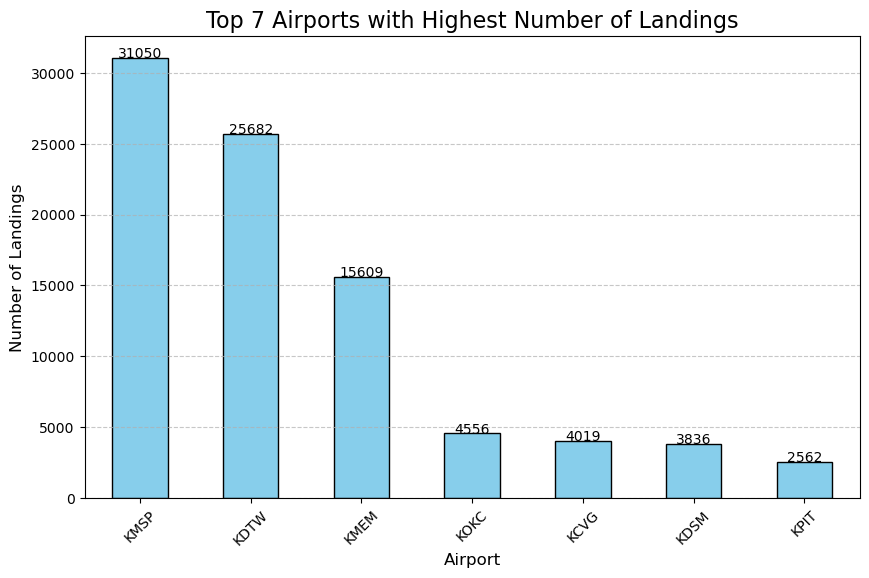

In [24]:
import matplotlib.pyplot as plt

# Get top 7 airports with the highest number of landings
top_airports = airportCounts.head(7)

# Plot the bar plot
_ = plt.figure(figsize=(10, 6))
_ = top_airports.plot(kind='bar', color='skyblue', edgecolor='black')

# Add labels and title
_ = plt.title('Top 7 Airports with Highest Number of Landings', fontsize=16)
_ = plt.xlabel('Airport', fontsize=12)
_ = plt.ylabel('Number of Landings', fontsize=12)

# Display the value on top of each bar
for i, value in enumerate(top_airports):
    _ = plt.text(i, value + 2, str(value), ha='center', fontsize=10)

# Rotate x-axis labels for better visibility
_ = plt.xticks(rotation=45)
_ = plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

__Airports with most number of long landings__

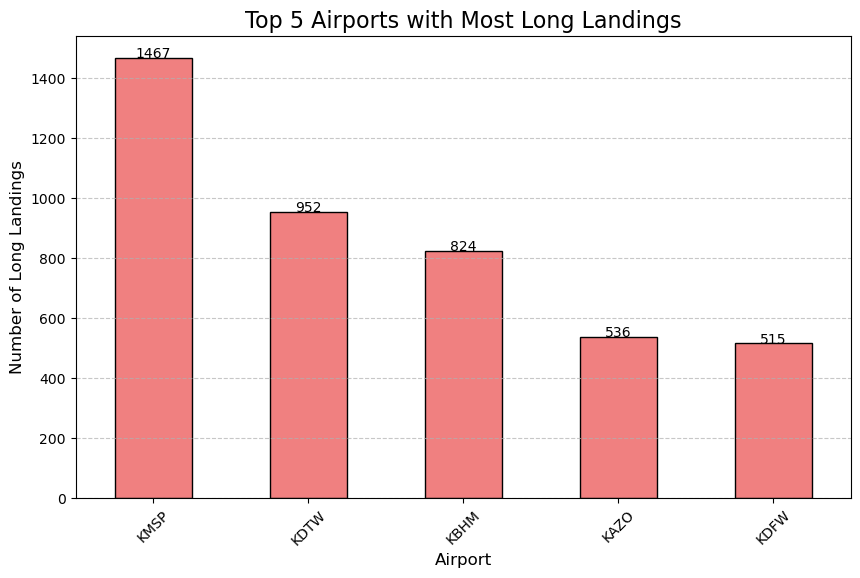

In [25]:
# Filter only long landings
long_landing_counts = MagneticHeadingDataLanding[MagneticHeadingDataLanding['isLongLanding'] == 1]['NearestAirport'].value_counts().head(5)

# Plot the bar plot
_ = plt.figure(figsize=(10, 6))
_ = long_landing_counts.plot(kind='bar', color='lightcoral', edgecolor='black')

# Add labels and title
_ = plt.title('Top 5 Airports with Most Long Landings', fontsize=16)
_ = plt.xlabel('Airport', fontsize=12)
_ = plt.ylabel('Number of Long Landings', fontsize=12)

# Display the value on top of each bar
for i, value in enumerate(long_landing_counts):
    _ = plt.text(i, value + 1, str(value), ha='center', fontsize=10)

# Rotate x-axis labels for better visibility
_ = plt.xticks(rotation=45)
_ = plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

__Airports with high/low percent of long landings__

In [26]:
longLandingAirports = MagneticHeadingDataLanding.loc[MagneticHeadingDataLanding['isLongLanding'] == 1]['NearestAirport'].value_counts()
resultDf = pd.concat([airportCounts, longLandingAirports], axis=1).dropna()
resultDf.columns = ['Total No. of Landings', 'Total No. of Long Landings']
resultDf = resultDf.loc[resultDf['Total No. of Landings'] > 100]

In [27]:
# runwayCountsDf = MagneticHeadingDataLanding['Airport_Runway'].value_counts()
# MagneticHeadingDataLanding.loc[(MagneticHeadingDataLanding['isLongLanding'] == 1) & (runwayCountsDf.loc[MagneticHeadingDataLanding['Airport_Runway']] > 10)]['Airport_Runway'].value_counts().sort_values(ascending=False)

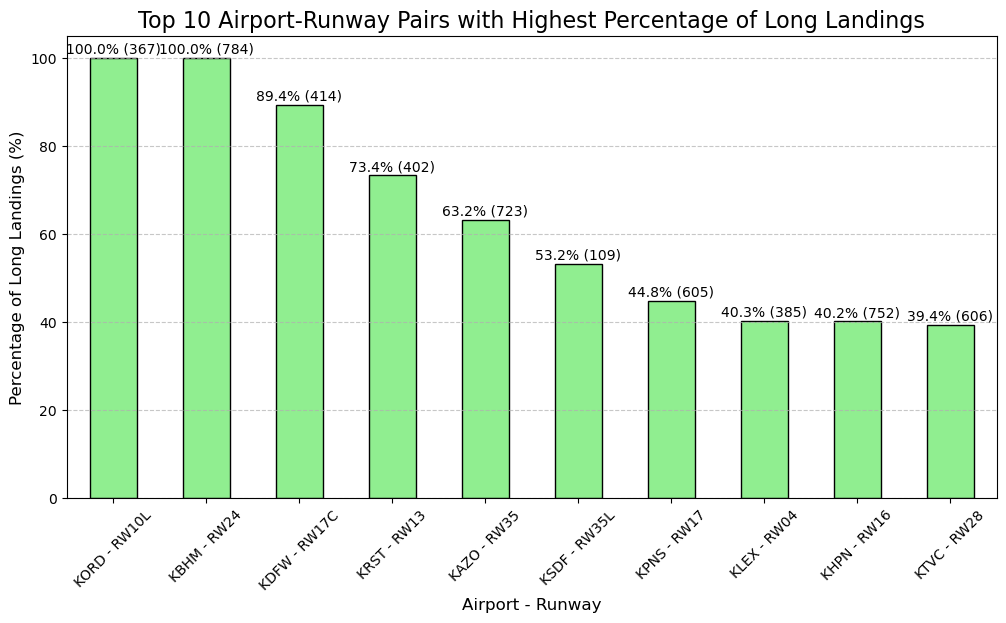

In [31]:
# Group by both Airport and Runway
MagneticHeadingDataLanding['Airport_Runway'] = MagneticHeadingDataLanding['NearestAirport'] + ' - ' + MagneticHeadingDataLanding['NearestRunway']

# Filter out runways with fewer than 50 landings
valid_runways = MagneticHeadingDataLanding.groupby('Airport_Runway')['isLongLanding'].count()
valid_runways = valid_runways[valid_runways >= 100]

# Calculate top 10 highest percentages for valid runways
top_10_highest = ((MagneticHeadingDataLanding.groupby('Airport_Runway')['isLongLanding'].sum() / 
                   MagneticHeadingDataLanding.groupby('Airport_Runway')['isLongLanding'].count()) * 100
                ).loc[valid_runways.index].sort_values(ascending=False).head(10)

# Get the corresponding number of landings
landings = valid_runways.loc[top_10_highest.index]

# Plot top 10 highest percentage of long landings by runway
_ = plt.figure(figsize=(12, 6))
_ = top_10_highest.plot(kind='bar', color='lightgreen', edgecolor='black')

_ = plt.title('Top 10 Airport-Runway Pairs with Highest Percentage of Long Landings', fontsize=16)
_ = plt.xlabel('Airport - Runway', fontsize=12)
_ = plt.ylabel('Percentage of Long Landings (%)', fontsize=12)

# Display values on top of bars (include percentage and no. of landings)
for i, (value, landing_count) in enumerate(zip(top_10_highest, landings)):
    _ = plt.text(i, value + 1, f'{value:.1f}% ({int(landing_count)})', ha='center', fontsize=10)

_ = plt.xticks(rotation=45)
_ = plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

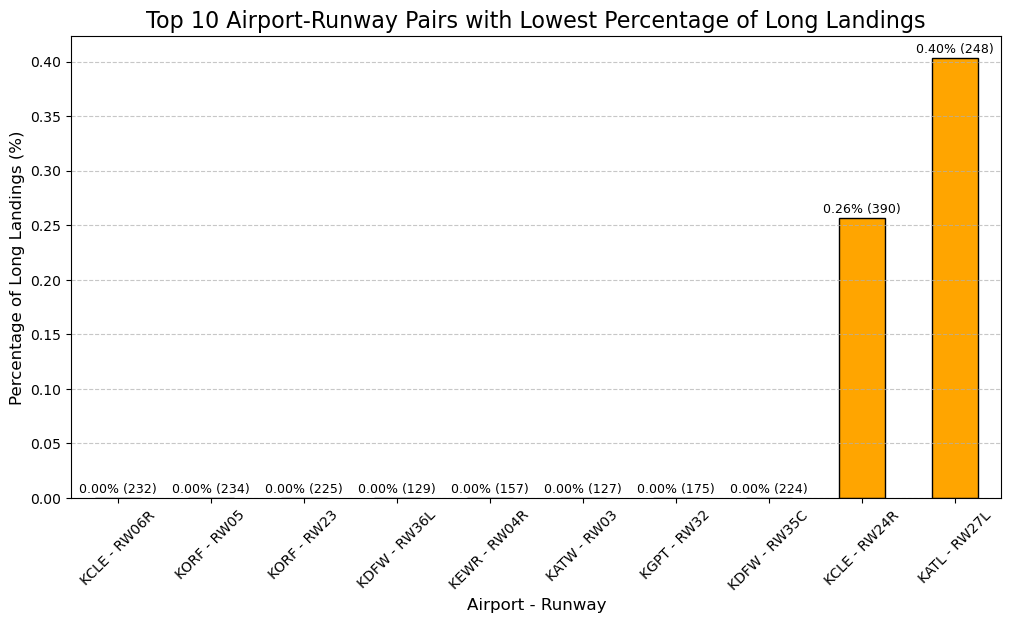

In [37]:
# Group by Airport and Runway, and filter out runway pairs with fewer than 50 landings
runway_counts = MagneticHeadingDataLanding.groupby('Airport_Runway')['isLongLanding'].count()
valid_runways = runway_counts[runway_counts >= 100].index

# Filter the dataset to include only valid runway pairs
filtered_df = MagneticHeadingDataLanding[MagneticHeadingDataLanding['Airport_Runway'].isin(valid_runways)]

# Get top 10 airport-runway pairs with lowest percentage of long landings
top_10_lowest = ((filtered_df.groupby('Airport_Runway')['isLongLanding'].sum() / 
                  filtered_df.groupby('Airport_Runway')['isLongLanding'].count()) * 100).sort_values(ascending=True).head(10)

# Get the corresponding number of landings
landings = filtered_df.groupby('Airport_Runway')['isLongLanding'].count().loc[top_10_lowest.index]

# Plot top 10 lowest percentage of long landings by runway
_ = plt.figure(figsize=(12, 6))
_ = top_10_lowest.plot(kind='bar', color='orange', edgecolor='black')

_ = plt.title('Top 10 Airport-Runway Pairs with Lowest Percentage of Long Landings', fontsize=16)
_ = plt.xlabel('Airport - Runway', fontsize=12)
_ = plt.ylabel('Percentage of Long Landings (%)', fontsize=12)

# Display values on top of bars (include percentage and no. of landings)
for i, (value, landing_count) in enumerate(zip(top_10_lowest, landings)):
    _ = plt.text(i, value+0.005, f'{value:.2f}% ({int(landing_count)})', ha='center', fontsize=9)

_ = plt.xticks(rotation=45)
_ = plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

__Some more analysis on this__

In [38]:
runway_df['ThrCrossHeight'].describe()

count    7049.000000
mean       47.139169
std         6.361536
min        20.000000
25%        40.000000
50%        50.000000
75%        50.000000
max        80.000000
Name: ThrCrossHeight, dtype: float64

In [39]:
MagneticHeadingDataLanding['RWElevation'] = MagneticHeadingDataLanding['MinIdx'].apply(lambda x: runway_df.loc[x, 'Elevation'])
MagneticHeadingDataLanding['ThrCrossHeight'] = MagneticHeadingDataLanding['MinIdx'].apply(lambda x: runway_df.loc[x, 'ThrCrossHeight'])

In [40]:
# MagneticHeadingDataLanding.loc[MagneticHeadingDataLanding['isLongLanding'] == 0]['RunwayLength'].describe()
MagneticHeadingDataLanding.loc[MagneticHeadingDataLanding['isLongLanding'] == 1]['RWElevation'].describe()

count    10506.000000
mean       752.591091
std        603.129723
min          8.000000
25%        562.000000
50%        672.000000
75%        859.000000
max       7820.000000
Name: RWElevation, dtype: float64

In [41]:
MagneticHeadingDataLanding.loc[MagneticHeadingDataLanding['isLongLanding'] == 1]['ThrCrossHeight'].describe()

count    10506.000000
mean        54.129069
std          4.394287
min         37.000000
25%         52.000000
50%         54.000000
75%         56.000000
max         80.000000
Name: ThrCrossHeight, dtype: float64

In [43]:
MagneticHeadingDataLanding.loc[MagneticHeadingDataLanding['isLongLanding'] == 1]['RunwayLength'].describe()
MagneticHeadingDataLanding.loc[MagneticHeadingDataLanding['isLongLanding'] == 0]['RunwayLength'].describe()

count    10506.000000
mean      9180.445269
std       2075.005284
min       3901.000000
25%       7301.000000
50%       9000.000000
75%      10114.000000
max      13401.000000
Name: RunwayLength, dtype: float64

count    132097.000000
mean       9237.485658
std        1235.169915
min        3078.000000
25%        8200.000000
50%        9301.000000
75%       10000.000000
max       16000.000000
Name: RunwayLength, dtype: float64

In [45]:
MagneticHeadingDataLanding.loc[MagneticHeadingDataLanding['RunwayLength'] >= 8000]['isLongLanding'].value_counts()
MagneticHeadingDataLanding.loc[MagneticHeadingDataLanding['RunwayLength'] < 8000]['isLongLanding'].value_counts()

isLongLanding
0.0    119035
1.0      7506
Name: count, dtype: int64

isLongLanding
0.0    13062
1.0     3000
Name: count, dtype: int64

### Approach 4
__Same as the previous approach, just use updated touchdown coordinates using the N1_1 variable__

In [20]:
def fetchEndingCoords(row):
    """
    Fetches the ending coordinates of the runway.
    
    Params:
    - row: DataFrame row containing the runway data
    
    Returns:
    - Ending coordinates of the runway
    """
    TargetRow = runway_df.loc[(runway_df['Airport'] == row['Airport']) & (runway_df['Length'] == row['Length']) & (runway_df['Ident'] != row['Ident'])]
    if not TargetRow.empty:
        return TargetRow['Starting Coordinates'].iloc[0]  # Ensure a single value is returned
    return None

In [ ]:
runway_df.rename(columns = {'combined_coordinates':'Starting Coordinates'}, inplace = True)

In [ ]:
runway_df.head()

,Airport,Ident,RevCode,BiDir,VFR,MagBearing,Length,Latitude,FORMATTED LATITUDE,Longitude,FORMATTED LONGITUDE,GOOGLE EARTH,ThrDisp,Elevation,ILS Navaid,ILS Cat,ILS LBearing,ThrCrossHeight,GPIP_Offset(Assuming 3 degree glideslope),Starting Coordinates
0,KAAA,RW03,B,,,35,4000,40.153308,40 09 11.91N,-89.339975,089 20 23.91W,40 09 11.91N 089 20 23.91W,,593,---,NaN,NaN,36,NaN,"[40.153308333333335, -89.339975]"
1,KAAA,RW21,B,,,215,4000,40.162267,40 09 44.16N,-89.331692,089 19 54.09W,40 09 44.16N 089 19 54.09W,,594,---,NaN,NaN,36,NaN,"[40.16226666666667, -89.33169166666666]"
2,KAAF,RW06,B,,,63,5271,29.722344,29 43 20.44N,-85.037422,085 02 14.72W,29 43 20.44N 085 02 14.72W,,19,---,NaN,NaN,40,NaN,"[29.722344444444442, -85.03742222222222]"
3,KAAF,RW14,B,,,138,5425,29.732786,29 43 58.03N,-85.034739,085 02 05.06W,29 43 58.03N 085 02 05.06W,,15,---,NaN,NaN,40,NaN,"[29.73278611111111, -85.03473888888888]"
4,KAAF,RW18,B,,,183,5251,29.736433,29 44 11.16N,-85.023072,085 01 23.06W,29 44 11.16N 085 01 23.06W,,15,---,NaN,NaN,40,NaN,"[29.736433333333334, -85.02307222222223]"


In [ ]:
runway_df['Ending Coordinates'] = runway_df.apply(fetchEndingCoords, axis = 1)

In [ ]:
runway_df.loc[runway_df['Ending Coordinates'].isna()]
runway_df.at[3970, 'Ending Coordinates'] = [30.84222222, -85.1705555556]
runway_df.at[3972, 'Ending Coordinates'] = [30.8277777778, -85.1855555556]
runway_df.at[3696, 'Ending Coordinates'] = [31.8836111111, -81.5533333333]
runway_df.at[3700, 'Ending Coordinates'] = [31.8813888889, -81.5747222222]

,Airport,Ident,RevCode,BiDir,VFR,MagBearing,Length,Latitude,FORMATTED LATITUDE,Longitude,...,GOOGLE EARTH,ThrDisp,Elevation,ILS Navaid,ILS Cat,ILS LBearing,ThrCrossHeight,GPIP_Offset(Assuming 3 degree glideslope),Starting Coordinates,Ending Coordinates
3696,KLHW,RW15L,1,,,145,4999,31.894350,31 53 39.66N,-81.563644,...,31 53 39.66N 081 33 49.12W,,39,---,NaN,NaN,50,NaN,"[31.89435, -81.56364444444444]",None
3700,KLHW,RW24R,1,,,235,6505,31.892994,31 53 34.78N,-81.558750,...,31 53 34.78N 081 33 31.50W,,33,---,NaN,NaN,50,NaN,"[31.892994444444444, -81.55875]",None
3970,KMAI,RW08,1,,,84,4895,30.840625,30 50 26.25N,-85.185833,...,30 50 26.25N 085 11 09.00W,,110,---,NaN,NaN,40,NaN,"[30.840625, -85.18583333333333]",None
3972,KMAI,RW18,1,,,182,4896,30.840756,30 50 26.72N,-85.185650,...,30 50 26.72N 085 11 08.34W,,110,---,NaN,NaN,37,NaN,"[30.840755555555553, -85.18565000000001]",None


In [24]:
def perpendicular_distance(P, A, B):
    """
    Compute perpendicular distance from point P to line segment AB.
    P, A, B are (lat, lon) coordinate pairs.
    """
    P, A, B = np.array(P), np.array(A), np.array(B)
    AB = B - A
    AP = P - A
    t = np.dot(AP, AB) / np.dot(AB, AB)  # Projection scalar

    # Clamp t to [0, 1] to keep within segment limits
    t = np.clip(t, 0, 1)
    Q = A + t * AB  # Closest point on the runway
    return haversine(P, Q, Unit.FEET)  # Distance in feet

def compute_combined_scores_perpendicular_N1Approach(N1ApproachTouchdownCoordinates, runway_df):
    flight_headings = N1ApproachTouchdownCoordinates['MagneticHeadingUpdated'].values
    touchdown_coords = N1ApproachTouchdownCoordinates[['Latitude', 'Longitude']].values
    
    runway_bearings = runway_df['MagBearing'].values
    runway_start = np.array(runway_df['Starting Coordinates'].values)
    runway_end = np.array(runway_df['Ending Coordinates'].values)

    # Compute angular differences
    angular_diff_matrix = np.minimum(
    np.abs(flight_headings[:, None] - runway_bearings),
    360 - np.abs(flight_headings[:, None] - runway_bearings)
)

    # Compute perpendicular distances (vectorized)
    perp_dist_matrix = np.array([
        [perpendicular_distance(flight, A, B) for A, B in zip(runway_start, runway_end)]
        for flight in touchdown_coords
    ])

    # Normalize
    angular_diff_norm = (angular_diff_matrix - angular_diff_matrix.mean(axis=1, keepdims=True)) / angular_diff_matrix.std(axis=1, keepdims=True)
    perp_dist_norm = (perp_dist_matrix - perp_dist_matrix.mean(axis=1, keepdims=True)) / perp_dist_matrix.std(axis=1, keepdims=True)

    # Weighted sum
    w1, w2 = 0.3, 0.7
    combined_scores = w1 * angular_diff_norm + w2 * perp_dist_norm
    # Find best runway
    min_indices = np.argmin(combined_scores, axis=1)
    N1ApproachTouchdownCoordinates['MinIdx'] = min_indices

    return N1ApproachTouchdownCoordinates

In [25]:
compute_combined_scores_perpendicular_N1Approach(N1ApproachTouchdownCoordinates, runway_df)

,Flights,Timestamps,TouchdownIdx,Latitude,Longitude,MagneticHeading,MagneticHeadingUpdated,MinIdx
0,666_8,666200306240517.mat,26451,35.027333,-89.972696,-0.373524,359.626476,4095
1,666_8,666200306240815.mat,19367,35.402244,-97.588985,175.765015,175.765015,4837
2,666_8,666200306241019.mat,17812,35.052397,-89.975453,176.473618,176.473618,4089
3,666_8,666200306241258.mat,21585,35.395033,-97.598758,66.168678,66.168678,5028
4,666_8,666200306241521.mat,36245,42.202094,-83.367689,38.390579,38.390579,1706
...,...,...,...,...,...,...,...,...
1596,677_2,677200203291357.mat,36878,35.024760,-89.972543,-2.032410,357.967590,4095
1597,677_2,677200203291718.mat,34114,40.687867,-74.176087,38.692692,38.692692,2077
1598,677_2,677200203300412.mat,39008,35.036776,-89.974596,-93.457901,266.542099,4092
1599,677_2,677200203300731.mat,33322,39.879857,-75.233168,170.568634,170.568634,5209


In [26]:
N1ApproachTouchdownCoordinates['NearestRunway'] = N1ApproachTouchdownCoordinates['MinIdx'].apply(lambda x: runway_df.loc[x,'Ident'])
N1ApproachTouchdownCoordinates['NearestAirport'] = N1ApproachTouchdownCoordinates['MinIdx'].apply(lambda x: runway_df.loc[x,'Airport'])
N1ApproachTouchdownCoordinates['AirportCoords'] = N1ApproachTouchdownCoordinates['MinIdx'].apply(lambda x: runway_df.loc[x,'Starting Coordinates'])

In [27]:
N1ApproachTouchdownCoordinates['RunwayLength'] = N1ApproachTouchdownCoordinates['MinIdx'].apply(lambda x: runway_df.loc[x, 'Length'])

In [28]:
N1ApproachTouchdownCoordinates.head()

,Flights,Timestamps,TouchdownIdx,Latitude,Longitude,MagneticHeading,MagneticHeadingUpdated,MinIdx,NearestRunway,NearestAirport,AirportCoords,RunwayLength
0,666_8,666200306240517.mat,26451,35.027333,-89.972696,-0.373524,359.626476,4095,RW36R,KMEM,"[35.02408888888889, -89.97242222222222]",9000
1,666_8,666200306240815.mat,19367,35.402244,-97.588985,175.765015,175.765015,4837,RW17L,KOKC,"[35.40515555555555, -97.58895833333332]",9803
2,666_8,666200306241019.mat,17812,35.052397,-89.975453,176.473618,176.473618,4089,RW18C,KMEM,"[35.05458333333333, -89.97617222222222]",11120
3,666_8,666200306241258.mat,21585,35.395033,-97.598758,66.168678,66.168678,5028,RW03,KOUN,"[35.236225, -97.47580833333333]",4748
4,666_8,666200306241521.mat,36245,42.202094,-83.367689,38.390579,38.390579,1706,RW04R,KDTW,"[42.203541666666666, -83.37036388888889]",12003


In [29]:
N1ApproachTouchdownCoordinates['NearestAirport'].value_counts()

NearestAirport
KMSP    266
KDTW    230
KMEM    172
KOKC     38
KOZW     33
       ... 
KHNB      1
KLEB      1
KSUE      1
KOCQ      1
KIOW      1
Name: count, Length: 160, dtype: int64

In [ ]:
import folium
import numpy as np

# Define the airport you want to analyze
selected_airport = "KMSP"

# Filter flights and runways for this airport
filtered_flights = N1ApproachTouchdownCoordinates[N1ApproachTouchdownCoordinates['NearestAirport'] == selected_airport]
filtered_runways = runway_df[runway_df['Airport'] == selected_airport]

# Get center of the map
center_lat, center_lon = filtered_flights[['Latitude', 'Longitude']].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=10)

# Assign unique colors to each runway
runway_ids = filtered_runways.index.unique()
colors = np.random.choice([
    'red', 'blue', 'green', 'purple', 'orange', 'darkred', 'cadetblue', 'darkblue'
], size=len(runway_ids), replace=True)
runway_color_map = dict(zip(runway_ids, colors))

# Plot runways
for idx, row in filtered_runways.iterrows():
    folium.Marker(
        location=row['Starting Coordinates'],
        icon=folium.Icon(color=runway_color_map[idx], icon="plane"),
        tooltip=f"Runway {idx}"
    ).add_to(m)

# Plot landings, coloring by assigned runway and long landing status
for _, row in filtered_flights.iterrows():
    assigned_runway = row['MinIdx']
    is_long_landing = row['isLongLanding']
    
    # If long landing, change border color to red, else match runway color
    border_color = 'red' if is_long_landing == 1 else runway_color_map.get(assigned_runway, 'black')
    
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5,
        color=border_color,  # Border color
        fill=True,
        fill_color=runway_color_map.get(assigned_runway, 'black'),
        fill_opacity=0.7,
        tooltip=f"Flight Landing (Runway {assigned_runway}) - Long Landing: {'Yes' if is_long_landing else 'No'}"
    ).add_to(m)

# Save and display the map
m.save(f"{selected_airport}_landing_visualization.html")

In [35]:
import webbrowser
webbrowser.open("KMSP_landing_visualization.html")

True

__Let's predict Long Landing__

In [30]:
def predictLongLanding(row):
    touchdownCoords = [row['Latitude'], row['Longitude']]
    AirportCoords = row['AirportCoords']
    RunwayLength = row['RunwayLength']
    touchdownDistance = haversine(touchdownCoords, AirportCoords, Unit.FEET)
    if touchdownDistance <= RunwayLength/3:
        return 0, touchdownDistance
    else: return 1, touchdownDistance

In [31]:
N1ApproachTouchdownCoordinates[['isLongLanding', 'TouchdownDistance']] = N1ApproachTouchdownCoordinates.apply(
lambda row: pd.Series(predictLongLanding(row)), axis=1)

In [32]:
N1ApproachTouchdownCoordinates['isLongLanding'].value_counts()

isLongLanding
0.0    1060
1.0     541
Name: count, dtype: int64